In [3]:
import os

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score

In [5]:
# Load data
data = pd.read_csv("../data/processed/final_dataset.csv")

In [6]:
MAIN_FEATURES = [
    'age',
    'gender',
    'smoker',
    'known_blood_sugar',
    'known_cholesterol',
    'under_treatment',
    'health_condition',
]

In [8]:
print(data.shape)
print(data.columns.tolist())
data[MAIN_FEATURES + ['bp_systolic', 'bp_diastolic']].head()

(15219, 19)
['id', 'datetime', 'terminal', 'postal_code', 'town', 'district', 'state', 'health_condition', 'birth_year', 'gender', 'smoker', 'known_blood_sugar', 'known_cholesterol', 'under_treatment', 'est_bp_systolic', 'est_bp_diastolic', 'bp_systolic', 'bp_diastolic', 'age']


,age,gender,smoker,known_blood_sugar,known_cholesterol,under_treatment,health_condition,bp_systolic,bp_diastolic
0,39.0,m,False,True,False,False,1.0,179,111
1,38.0,m,False,False,False,False,1.0,109,80
2,33.0,m,True,False,False,False,1.0,128,108
3,45.0,m,False,False,False,False,1.0,130,90
4,28.0,f,False,False,False,False,2.0,144,103


In [7]:
def train_rf_model(X_train, X_test, y_train, y_test):
    print(f"\nTraining set : {len(X_train):,} rows")
    print(f"Test set     : {len(X_test):,} rows")
    
    # Build RF model
    rf = RandomForestRegressor(
        n_estimators=500,
        max_features='sqrt',
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,max_depth=None
    )
    
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    return rf, y_pred

In [ ]:
def plot_actual_vs_predicted(y_true, y_pred, title, save_path=None):
    plt.figure(figsize=(6,5))
    
    plt.scatter(y_true, y_pred, alpha=0.4, s=15, color='teal')
    
    # Perfect prediction line
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--', lw=2)

    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(title)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()

def plot_feature_importance(importance_df, title, save_path=None):
    plt.figure(figsize=(6,5))
    
    plt.barh(importance_df['feature'], importance_df['importance'], color='teal')
    
    plt.xlabel('Importance')
    plt.title(title)
    plt.gca().invert_yaxis()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()

### Dialstolic BP Prediction

In [ ]:
FEATURES = MAIN_FEATURES.copy()
FEATURES.extend(['bp_systolic'])
X = data[FEATURES]
y = data['bp_diastolic']

In [ ]:
# Train/Test Split
(X_train, X_test,
 y_train, y_test) = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42    
)

In [ ]:
rf, y_pred = train_rf_model(X_train, X_test, y_train, y_test)

# Cross-validation
scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("Cross-validated R² scores (Diastolic):", scores)
print("Mean CV R²:", scores.mean())


Training set : 12,175 rows
Test set     : 3,044 rows
Cross-validated R² scores (Diastolic): [0.48865302 0.46051188 0.4196023  0.45665475 0.42360965]
Mean CV R²: 0.4498063179864533


In [ ]:
# Evaluate the model
r2_dia = r2_score(y_test, y_pred)
mae_dia = mean_absolute_error(y_test, y_pred)
rmse_dia = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Evaluation ---")
print(f"Diastolic BP R²: {r2_dia:.3f}, MAE: {mae_dia:.2f}, RMSE: {rmse_dia:.2f}")

# Feature Importance
imp = pd.DataFrame({
    'feature':    FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(imp.to_string(index=False))

--- Model Evaluation ---
Diastolic BP R²: 0.479, MAE: 7.73, RMSE: 10.52

Feature Importance:
          feature  importance
      bp_systolic    0.763533
              age    0.162284
           gender    0.020977
 health_condition    0.020427
  under_treatment    0.012036
known_cholesterol    0.007704
           smoker    0.006545
known_blood_sugar    0.006492


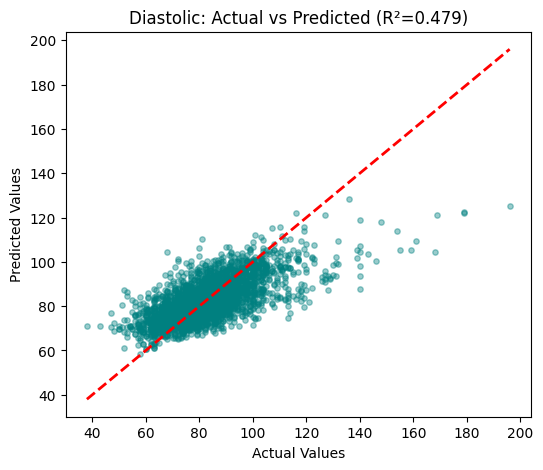

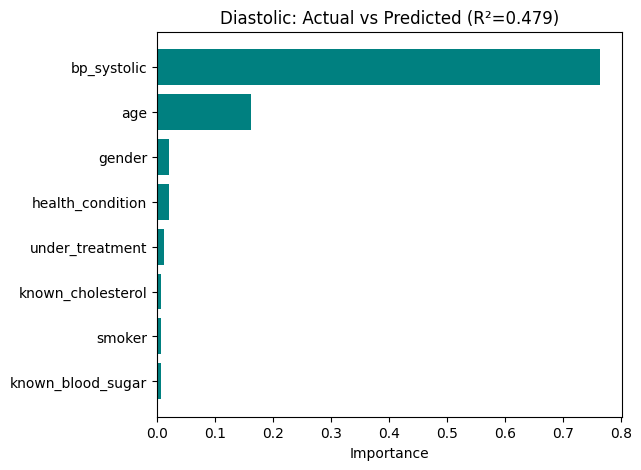


MODEL SUMMARY
                           Diastolic
R²                            0.4785
MAE (mmHg)                      7.73
RMSE (mmHg)                    10.52


In [ ]:
plot_actual_vs_predicted(y_test, y_pred, title=f'Diastolic: Actual vs Predicted (R²={r2_dia:.3f})', save_path='../presentation/figures/bp_dia_prediction_fig.png')
plot_feature_importance(imp, title=f'Diastolic: Actual vs Predicted (R²={r2_dia:.3f})', save_path='../presentation/figures/bp_dia_featimp_fig.png')

# Summary 
print("\n" + "="*45)
print("MODEL SUMMARY")
print("="*45)
print(f"{'':25} {'Diastolic':>10}")
print(f"{'R²':25} {r2_dia:>10.4f}")
print(f"{'MAE (mmHg)':25} {mae_dia:>10.2f}")
print(f"{'RMSE (mmHg)':25} {rmse_dia:>10.2f}")

### Systolic BP Prediction

In [ ]:
FEATURES = MAIN_FEATURES.copy()
FEATURES.extend(['bp_diastolic'])
X = data[FEATURES]
y = data['bp_systolic']

In [ ]:
# Train/Test Split
(X_train, X_test,
 y_train, y_test) = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42    
)

In [ ]:
rf, y_pred = train_rf_model(X_train, X_test, y_train, y_test)

# Cross-validation
scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("Cross-validated R² scores (Diastolic):", scores)
print("Mean CV R²:", scores.mean())


Training set : 12,175 rows
Test set     : 3,044 rows
Cross-validated R² scores (Diastolic): [0.54227939 0.48821063 0.47894034 0.51952046 0.47861488]
Mean CV R²: 0.5015131403500589


In [ ]:
# Evaluate the model
r2_sys = r2_score(y_test, y_pred)
mae_sys = mean_absolute_error(y_test, y_pred)
rmse_sys = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Evaluation ---")
print(f"Systolic BP R²: {r2_sys:.3f}, MAE: {mae_sys:.2f}, RMSE: {rmse_sys:.2f}")

# Feature Importance
imp = pd.DataFrame({
    'feature':    FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(imp.to_string(index=False))

--- Model Evaluation ---
Systolic BP R²: 0.526, MAE: 10.31, RMSE: 13.18

Feature Importance:
          feature  importance
     bp_diastolic    0.665923
              age    0.211626
  under_treatment    0.056052
           gender    0.024952
 health_condition    0.016818
known_cholesterol    0.009390
known_blood_sugar    0.009243
           smoker    0.005996


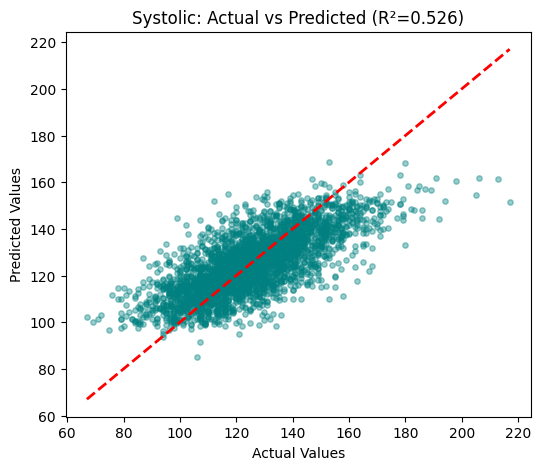

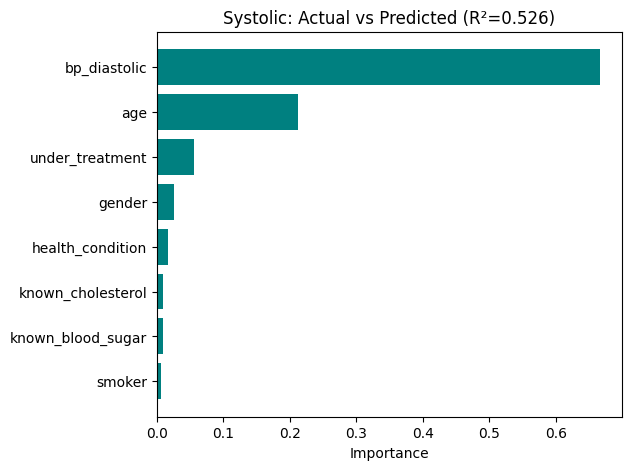


MODEL SUMMARY
                            Systolic
R²                            0.5264
MAE (mmHg)                     10.31
RMSE (mmHg)                    13.18


In [ ]:
plot_actual_vs_predicted(y_test, y_pred, title=f'Systolic: Actual vs Predicted (R²={r2_sys:.3f})', save_path='../presentation/figures/bp_sys_prediction_fig.png')
plot_feature_importance(imp, title=f'Systolic: Actual vs Predicted (R²={r2_sys:.3f})', save_path='../presentation/figures/bp_sys_featimp_fig.png')

# Summary 
print("\n" + "="*45)
print("MODEL SUMMARY")
print("="*45)
print(f"{'':25} {'Systolic':>10}")
print(f"{'R²':25} {r2_sys:>10.4f}")
print(f"{'MAE (mmHg)':25} {mae_sys:>10.2f}")
print(f"{'RMSE (mmHg)':25} {rmse_sys:>10.2f}")

### Multi target output

In [9]:
# Define input features and multi-output target
X_raw = data[MAIN_FEATURES].copy()
y = data[['bp_systolic', 'bp_diastolic']].copy()

# One-hot encode categorical variables
X = pd.get_dummies(
    X_raw,
    columns=['gender', 'smoker', 'known_blood_sugar', 'known_cholesterol', 'under_treatment'],
    drop_first=True
)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Final model features:")
print(X.columns.tolist())

Shape of X: (15219, 7)
Shape of y: (15219, 2)
Final model features:
['age', 'health_condition', 'gender_m', 'smoker_True', 'known_blood_sugar_True', 'known_cholesterol_True', 'under_treatment_True']


In [10]:
# Train/test split with stratification by age group
# This ensures that train and test contain similar age distributions.

age_groups = pd.cut(
    data['age'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['0-20', '21-40', '41-60', '61-80', '81-100']
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=age_groups
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nAge distribution in full data:")
print(age_groups.value_counts(normalize=True).sort_index())

Training set: (12175, 7)
Test set: (3044, 7)

Age distribution in full data:
age
0-20      0.123070
21-40     0.287272
41-60     0.403969
61-80     0.176293
81-100    0.009396
Name: proportion, dtype: float64


In [11]:
rf, y_pred = train_rf_model(X_train, X_test, y_train, y_test)


Training set : 12,175 rows
Test set     : 3,044 rows


In [12]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

# Separate actual and predicted values
y_test_sys = y_test['bp_systolic']
y_test_dia = y_test['bp_diastolic']

y_pred_sys = y_pred[:, 0]
y_pred_dia = y_pred[:, 1]

# Metrics for systolic BP
r2_sys = r2_score(y_test_sys, y_pred_sys)
mae_sys = mean_absolute_error(y_test_sys, y_pred_sys)
rmse_sys = root_mean_squared_error(y_test_sys, y_pred_sys)

# Metrics for diastolic BP
r2_dia = r2_score(y_test_dia, y_pred_dia)
mae_dia = mean_absolute_error(y_test_dia, y_pred_dia)
rmse_dia = root_mean_squared_error(y_test_dia, y_pred_dia)

# Print results
print("===== Multi-Output Random Forest Results =====\n")

print("SYSTOLIC BP")
print(f"R²   : {r2_sys:.3f}")
print(f"MAE  : {mae_sys:.2f} mmHg")
print(f"RMSE : {rmse_sys:.2f} mmHg\n")

print("DIASTOLIC BP")
print(f"R²   : {r2_dia:.3f}")
print(f"MAE  : {mae_dia:.2f} mmHg")
print(f"RMSE : {rmse_dia:.2f} mmHg")

===== Multi-Output Random Forest Results =====

SYSTOLIC BP
R²   : 0.130
MAE  : 14.14 mmHg
RMSE : 18.14 mmHg

DIASTOLIC BP
R²   : 0.042
MAE  : 10.50 mmHg
RMSE : 14.20 mmHg


In [13]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                  Feature  Importance
0                     age    0.680983
6    under_treatment_True    0.108434
2                gender_m    0.082492
1        health_condition    0.055918
5  known_cholesterol_True    0.027186
4  known_blood_sugar_True    0.026411
3             smoker_True    0.018575


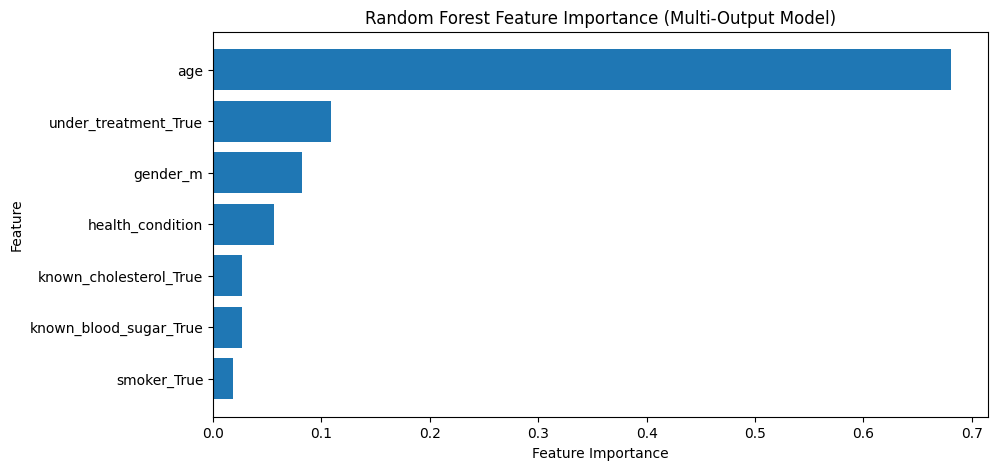

In [14]:
plt.figure(figsize=(10, 5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance (Multi-Output Model)")

plt.gca().invert_yaxis()

plt.show()

In [15]:
correlations = data[['age', 'bp_systolic', 'bp_diastolic']].corr()

print(correlations)

                   age  bp_systolic  bp_diastolic
age           1.000000     0.347105      0.143533
bp_systolic   0.347105     1.000000      0.660641
bp_diastolic  0.143533     0.660641      1.000000


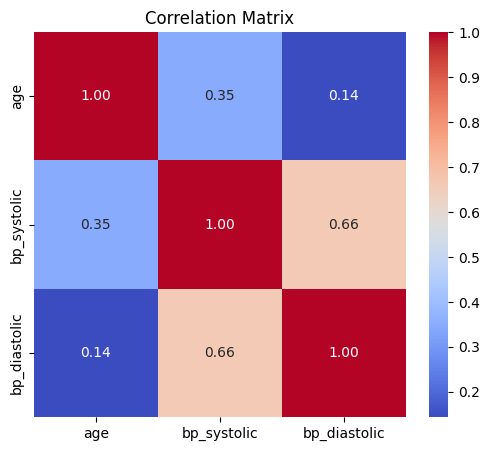

In [17]:
import seaborn as sns
plt.figure(figsize=(6, 5))

sns.heatmap(
    correlations,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

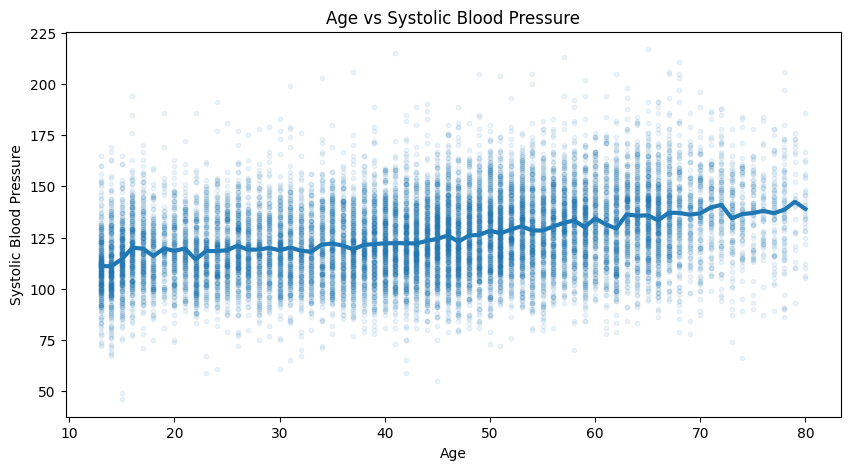

In [18]:
# Filter ages up to 80 for stable visualization
plot_data = data[data['age'] <= 80]

# Mean systolic BP by age
age_mean_bp = (
    plot_data
    .groupby('age')['bp_systolic']
    .mean()
)

plt.figure(figsize=(10, 5))

# Scatter of individual observations
plt.scatter(
    plot_data['age'],
    plot_data['bp_systolic'],
    alpha=0.08,
    s=10
)

# Mean trend line
plt.plot(
    age_mean_bp.index,
    age_mean_bp.values,
    linewidth=3
)

plt.xlabel("Age")
plt.ylabel("Systolic Blood Pressure")
plt.title("Age vs Systolic Blood Pressure")

plt.show()

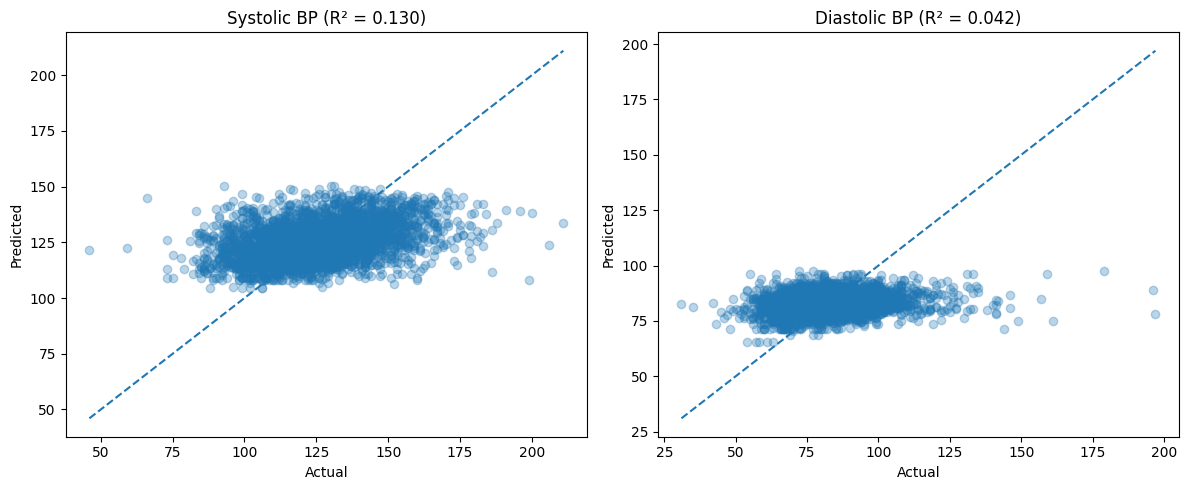

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Systolic
axes[0].scatter(
    y_test_sys,
    y_pred_sys,
    alpha=0.3
)

axes[0].plot(
    [y_test_sys.min(), y_test_sys.max()],
    [y_test_sys.min(), y_test_sys.max()],
    linestyle='--'
)

axes[0].set_title(f"Systolic BP (R² = {r2_sys:.3f})")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# Diastolic
axes[1].scatter(
    y_test_dia,
    y_pred_dia,
    alpha=0.3
)

axes[1].plot(
    [y_test_dia.min(), y_test_dia.max()],
    [y_test_dia.min(), y_test_dia.max()],
    linestyle='--'
)

axes[1].set_title(f"Diastolic BP (R² = {r2_dia:.3f})")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

In [20]:
from sklearn.model_selection import KFold, cross_val_score

In [21]:
# Cross-validation for systolic BP
rf_cv = RandomForestRegressor(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Systolic target
cv_scores_sys = cross_val_score(
    rf_cv,
    X,
    y['bp_systolic'],
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

# Diastolic target
cv_scores_dia = cross_val_score(
    rf_cv,
    X,
    y['bp_diastolic'],
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

print("===== 5-Fold Cross Validation =====\n")

print("Systolic BP")
print("Fold R² scores:", cv_scores_sys)
print(f"Mean R²: {cv_scores_sys.mean():.3f}")
print(f"Std Dev : {cv_scores_sys.std():.3f}\n")

print("Diastolic BP")
print("Fold R² scores:", cv_scores_dia)
print(f"Mean R²: {cv_scores_dia.mean():.3f}")
print(f"Std Dev : {cv_scores_dia.std():.3f}")

===== 5-Fold Cross Validation =====

Systolic BP
Fold R² scores: [0.11838871 0.15475634 0.14504298 0.13249653 0.15006715]
Mean R²: 0.140
Std Dev : 0.013

Diastolic BP
Fold R² scores: [0.01429991 0.05719582 0.02733751 0.04127114 0.03456585]
Mean R²: 0.035
Std Dev : 0.014


In [22]:
depth_results = []

depth_values = [3, 5, 10, 20, None]

for depth in depth_values:

    rf_temp = RandomForestRegressor(
        n_estimators=300,
        max_depth=depth,
        max_features='sqrt',
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        rf_temp,
        X,
        y['bp_systolic'],
        cv=kf,
        scoring='r2',
        n_jobs=-1
    )

    depth_results.append({
        'max_depth': str(depth),
        'mean_r2': scores.mean()
    })

depth_df = pd.DataFrame(depth_results)

print(depth_df)

  max_depth   mean_r2
0         3  0.137845
1         5  0.156897
2        10  0.163021
3        20  0.140112
4      None  0.140362


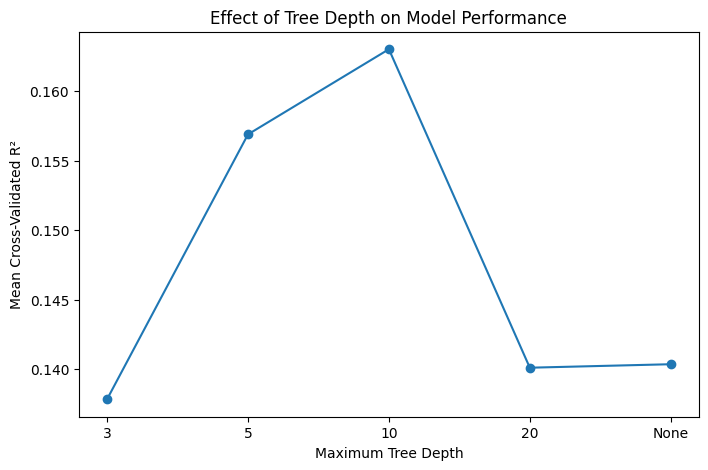

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    depth_df['max_depth'],
    depth_df['mean_r2'],
    marker='o'
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Mean Cross-Validated R²")
plt.title("Effect of Tree Depth on Model Performance")

plt.show()

In [24]:
# Convert datetime column
data['datetime'] = pd.to_datetime(data['datetime'])

# Extract temporal features
data['hour'] = data['datetime'].dt.hour
data['day_of_week'] = data['datetime'].dt.dayofweek
data['month'] = data['datetime'].dt.month

# Define season
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'

data['season'] = data['month'].apply(get_season)

# Check results
data[['datetime', 'hour', 'day_of_week', 'month', 'season']].head()

,datetime,hour,day_of_week,month,season
0,2006-04-27 10:49:12,10,3,4,spring
1,2006-04-27 11:10:46,11,3,4,spring
2,2006-04-27 11:21:09,11,3,4,spring
3,2006-04-27 11:32:59,11,3,4,spring
4,2006-04-27 12:01:48,12,3,4,spring


In [25]:
TEMPORAL_FEATURES = [
    'hour',
    'day_of_week',
    'month',
    'season'
]

ALL_FEATURES = MAIN_FEATURES + TEMPORAL_FEATURES

# Raw feature set
X_time_raw = data[ALL_FEATURES].copy()

# One-hot encoding
X_time = pd.get_dummies(
    X_time_raw,
    columns=[
        'gender',
        'smoker',
        'known_blood_sugar',
        'known_cholesterol',
        'under_treatment',
        'season'
    ],
    drop_first=True
)

print(X_time.shape)
print(X_time.columns.tolist())

(15219, 12)
['age', 'health_condition', 'hour', 'day_of_week', 'month', 'gender_m', 'smoker_True', 'known_blood_sugar_True', 'known_cholesterol_True', 'under_treatment_True', 'season_spring', 'season_summer']


In [26]:
# Stratified train/test split using the same age groups
X_time_train, X_time_test, y_time_train, y_time_test = train_test_split(
    X_time,
    y,
    test_size=0.2,
    random_state=42,
    stratify=age_groups
)

# Train improved multi-output Random Forest with best depth found earlier
rf_time = RandomForestRegressor(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=5,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_time.fit(X_time_train, y_time_train)

# Predict
y_time_pred = rf_time.predict(X_time_test)

# Evaluate
r2_sys_time = r2_score(y_time_test['bp_systolic'], y_time_pred[:, 0])
mae_sys_time = mean_absolute_error(y_time_test['bp_systolic'], y_time_pred[:, 0])
rmse_sys_time = root_mean_squared_error(y_time_test['bp_systolic'], y_time_pred[:, 0])

r2_dia_time = r2_score(y_time_test['bp_diastolic'], y_time_pred[:, 1])
mae_dia_time = mean_absolute_error(y_time_test['bp_diastolic'], y_time_pred[:, 1])
rmse_dia_time = root_mean_squared_error(y_time_test['bp_diastolic'], y_time_pred[:, 1])

print("===== Multi-Output RF with Temporal Features =====\n")

print("SYSTOLIC BP")
print(f"R²   : {r2_sys_time:.3f}")
print(f"MAE  : {mae_sys_time:.2f} mmHg")
print(f"RMSE : {rmse_sys_time:.2f} mmHg\n")

print("DIASTOLIC BP")
print(f"R²   : {r2_dia_time:.3f}")
print(f"MAE  : {mae_dia_time:.2f} mmHg")
print(f"RMSE : {rmse_dia_time:.2f} mmHg")

===== Multi-Output RF with Temporal Features =====

SYSTOLIC BP
R²   : 0.176
MAE  : 13.81 mmHg
RMSE : 17.66 mmHg

DIASTOLIC BP
R²   : 0.086
MAE  : 10.19 mmHg
RMSE : 13.87 mmHg


In [27]:
comparison_df = pd.DataFrame({
    'Model': [
        'Original Multi-Output RF',
        'Temporal Feature RF'
    ],
    'Systolic R²': [
        r2_sys,
        r2_sys_time
    ],
    'Diastolic R²': [
        r2_dia,
        r2_dia_time
    ]
})

print(comparison_df)

                      Model  Systolic R²  Diastolic R²
0  Original Multi-Output RF     0.129851      0.041546
1       Temporal Feature RF     0.175821      0.085781


In [28]:
# Feature importance for temporal feature model
feature_importance_time = pd.DataFrame({
    'Feature': X_time.columns,
    'Importance': rf_time.feature_importances_
})

feature_importance_time = feature_importance_time.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_time)

                   Feature  Importance
0                      age    0.422740
9     under_treatment_True    0.113022
2                     hour    0.092029
5                 gender_m    0.081727
3              day_of_week    0.075605
4                    month    0.064674
1         health_condition    0.040246
7   known_blood_sugar_True    0.027405
8   known_cholesterol_True    0.027314
11           season_summer    0.024752
6              smoker_True    0.017440
10           season_spring    0.013047


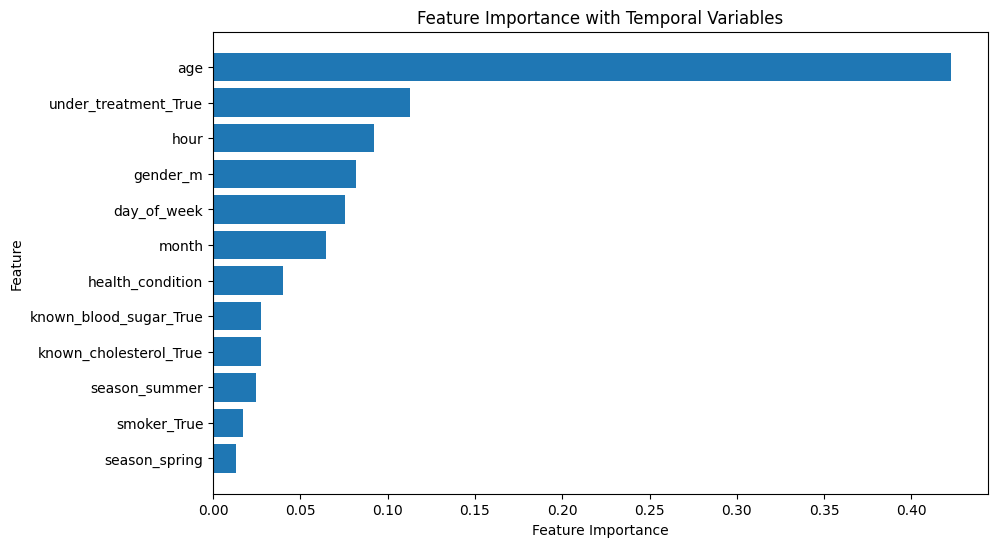

In [29]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_time['Feature'],
    feature_importance_time['Importance']
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance with Temporal Variables")

plt.gca().invert_yaxis()

plt.show()

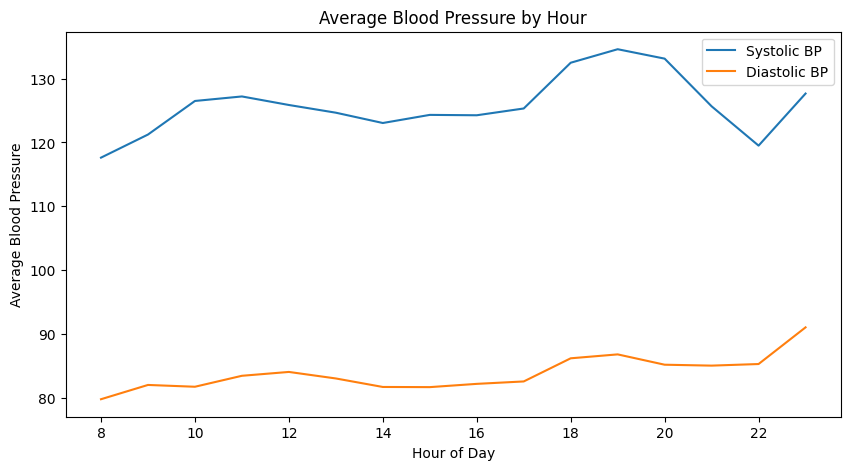

In [30]:
hourly_bp = (
    data.groupby('hour')[['bp_systolic', 'bp_diastolic']]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_bp.index,
    hourly_bp['bp_systolic'],
    label='Systolic BP'
)

plt.plot(
    hourly_bp.index,
    hourly_bp['bp_diastolic'],
    label='Diastolic BP'
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Blood Pressure")
plt.title("Average Blood Pressure by Hour")

plt.legend()
plt.show()

In [31]:
from sklearn.inspection import permutation_importance

In [34]:
# Custom scorer for systolic BP in multi-output model
def systolic_r2_scorer(estimator, X, y):
    
    y_pred = estimator.predict(X)
    
    return r2_score(
        y['bp_systolic'],
        y_pred[:, 0]
    )

# Permutation importance
perm_result_sys = permutation_importance(
    rf_time,
    X_time_test,
    y_time_test,
    scoring=systolic_r2_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Store results
perm_importance_sys = pd.DataFrame({
    'Feature': X_time.columns,
    'Importance': perm_result_sys.importances_mean
})

perm_importance_sys = perm_importance_sys.sort_values(
    by='Importance',
    ascending=False
)

print(perm_importance_sys)

                   Feature  Importance
0                      age    0.161117
9     under_treatment_True    0.048772
5                 gender_m    0.039017
4                    month    0.009745
2                     hour    0.009487
11           season_summer    0.007268
7   known_blood_sugar_True    0.005554
3              day_of_week    0.004654
8   known_cholesterol_True    0.003595
6              smoker_True    0.002059
10           season_spring    0.001778
1         health_condition    0.001222


In [35]:
# Custom scorer for diastolic BP in multi-output model
def diastolic_r2_scorer(estimator, X, y):
    
    y_pred = estimator.predict(X)
    
    return r2_score(
        y['bp_diastolic'],
        y_pred[:, 1]
    )

# Permutation importance
perm_result_dia = permutation_importance(
    rf_time,
    X_time_test,
    y_time_test,
    scoring=diastolic_r2_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Store results
perm_importance_dia = pd.DataFrame({
    'Feature': X_time.columns,
    'Importance': perm_result_dia.importances_mean
})

perm_importance_dia = perm_importance_dia.sort_values(
    by='Importance',
    ascending=False
)

print(perm_importance_dia)

                   Feature  Importance
0                      age    0.064297
5                 gender_m    0.033024
9     under_treatment_True    0.025310
4                    month    0.013908
2                     hour    0.009033
11           season_summer    0.008605
10           season_spring    0.008003
8   known_cholesterol_True    0.007171
7   known_blood_sugar_True    0.004577
1         health_condition    0.003440
3              day_of_week    0.003222
6              smoker_True    0.001076


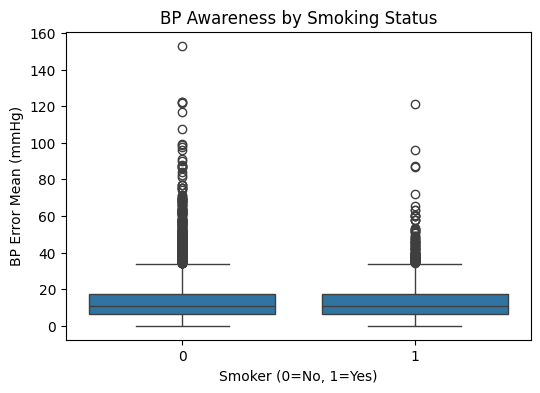

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='bp_error_mean', data=data)
plt.xlabel('Smoker (0=No, 1=Yes)')
plt.ylabel('BP Error Mean (mmHg)')
plt.title('BP Awareness by Smoking Status')
plt.show()

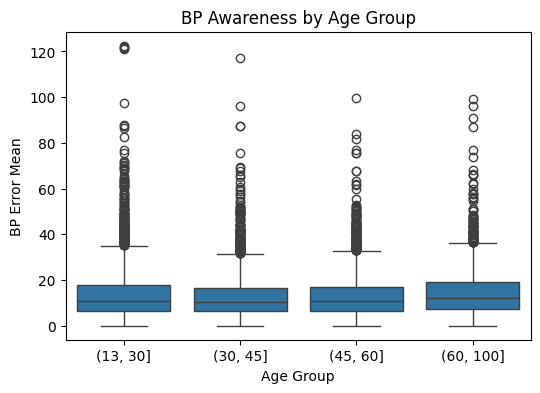

In [ ]:
data['age_bin'] = pd.cut(data['age'], bins=[13,30,45,60,100])
plt.figure(figsize=(6,4))
sns.boxplot(x='age_bin', y='bp_error_mean', data=data)
plt.xlabel('Age Group')
plt.ylabel('BP Error Mean')
plt.title('BP Awareness by Age Group')
plt.show()

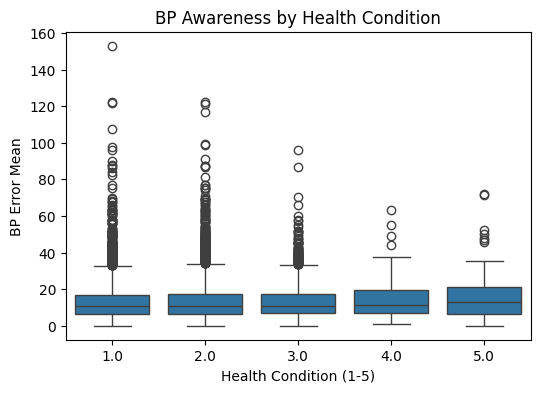

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='health_condition', y='bp_error_mean', data=data)
plt.xlabel('Health Condition (1-5)')
plt.ylabel('BP Error Mean')
plt.title('BP Awareness by Health Condition')
plt.show()